In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import os
import time

# Part-I Reading the imerge rainfall data downloaded from 
<!-- https://disc.gsfc.nasa.gov/ -->

In [2]:
# read the data starcture from the README file befor using this script

# path: the directory containing the raw IMERG NetCDF4 data subfolders::
path =  './IMERGL07/'

# Destination path for processed outputs or script repository:
dest =   './output/'

# Retrieve a list of subdirectories (assumed to be organized by observation year)
folder_names= os.listdir(path)

In [4]:
# Concatenate the time series from the folder named by the year of the observtion
# Collect all yearly datasets in a list 
datasets = []
start_time = time.time()
for year in range(int(folder_names[0]), int(folder_names[-1])+1):
    datasets.append(xr.open_mfdataset(path + str(year) + '/*.nc4'))

rainf = xr.concat(datasets, dim="time")
print(f'Time elapsed: {(time.time() - start_time)/60:.2f} min') # Time elapsed: 0.04 min
rainf

Time elapsed: 0.55 min


<xarray.Dataset> Size: 107MB
Dimensions:        (time: 1461, lon: 151, lat: 121)
Coordinates:
  * lat            (lat) float64 968B 2.95 3.05 3.15 3.25 ... 14.75 14.85 14.95
  * lon            (lon) float32 604B 33.05 33.15 33.25 ... 47.85 47.95 48.05
  * time           (time) datetime64[ns] 12kB 2020-01-01 ... 2023-12-31
Data variables:
    precipitation  (time, lon, lat) float32 107MB dask.array<chunksize=(1, 151, 121), meta=np.ndarray>
Attributes:
    BeginDate:       2020-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2020-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2020-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR-L.MS.MRG.3IMERG.20200101-S000000-E002959.0000.V07...
    title:           GPM IMERG Late Precipitation L3 1 day 0.1 degree x 0.1 d...
    DOI:             10.5067/GPM/IMERGDL/DAY/07
    ProductionTime:  2024-06-14T11:16:08.409Z
    history:         2024-09-02 14:42:48 GMT Hyrax-1.16.3 https://gpm1.gesdis...

In [5]:
# Reorder dimensions to the standard (time, lat, lon) format for spatial analysis
pr = rainf.transpose('time', 'lat', 'lon')

# Dynamically identify the variable; the first entry in the dataset's variable list
var_name = list(pr.data_vars)[0]

# Extract the DataArray from the Dataset 
pr = pr[var_name]
pr

<xarray.DataArray 'precipitation' (time: 1461, lat: 121, lon: 151)> Size: 107MB
dask.array<transpose, shape=(1461, 121, 151), dtype=float32, chunksize=(1, 121, 151), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 968B 2.95 3.05 3.15 3.25 ... 14.65 14.75 14.85 14.95
  * lon      (lon) float32 604B 33.05 33.15 33.25 33.35 ... 47.85 47.95 48.05
  * time     (time) datetime64[ns] 12kB 2020-01-01 2020-01-02 ... 2023-12-31
Attributes:
    units:         mm/day
    long_name:     Daily mean precipitation rate (combined microwave-IR) esti...
    origname:      precipitation
    fullnamepath:  /precipitation

In [6]:
# Resample the time series from daily to monthly intervals (1MS = Month Start)
monthly_rainfall = pr.resample(time="1MS").sum()#.compute()
monthly_rainfall.attrs['units'] = 'mm/month'
monthly_rainfall

<xarray.DataArray 'precipitation' (time: 48, lat: 121, lon: 151)> Size: 4MB
dask.array<transpose, shape=(48, 121, 151), dtype=float32, chunksize=(1, 121, 151), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 968B 2.95 3.05 3.15 3.25 ... 14.65 14.75 14.85 14.95
  * lon      (lon) float32 604B 33.05 33.15 33.25 33.35 ... 47.85 47.95 48.05
  * time     (time) datetime64[ns] 384B 2020-01-01 2020-02-01 ... 2023-12-01
Attributes:
    units:         mm/month
    long_name:     Daily mean precipitation rate (combined microwave-IR) esti...
    origname:      precipitation
    fullnamepath:  /precipitation

In [7]:
# Mean Monthly rainfal: the long-term monthly climatology 
mean_monthly_rainfall = monthly_rainfall.groupby('time.month').mean('time')
mean_monthly_rainfall

<xarray.DataArray 'precipitation' (month: 12, lat: 121, lon: 151)> Size: 877kB
dask.array<transpose, shape=(12, 121, 151), dtype=float32, chunksize=(1, 121, 151), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 968B 2.95 3.05 3.15 3.25 ... 14.65 14.75 14.85 14.95
  * lon      (lon) float32 604B 33.05 33.15 33.25 33.35 ... 47.85 47.95 48.05
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    units:         mm/month
    long_name:     Daily mean precipitation rate (combined microwave-IR) esti...
    origname:      precipitation
    fullnamepath:  /precipitation

In [8]:
#annual_rainfall: the time series into annual totals (Yearly Sum)
annual_rainfall =pr.groupby('time.year').sum('time')
annual_rainfall.attrs['units'] = 'mm/year'
annual_rainfall

<xarray.DataArray 'precipitation' (year: 4, lat: 121, lon: 151)> Size: 292kB
dask.array<transpose, shape=(4, 121, 151), dtype=float32, chunksize=(1, 121, 151), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 968B 2.95 3.05 3.15 3.25 ... 14.65 14.75 14.85 14.95
  * lon      (lon) float32 604B 33.05 33.15 33.25 33.35 ... 47.85 47.95 48.05
  * year     (year) int64 32B 2020 2021 2022 2023
Attributes:
    units:         mm/year
    long_name:     Daily mean precipitation rate (combined microwave-IR) esti...
    origname:      precipitation
    fullnamepath:  /precipitation

In [9]:
# mean_annual_rainfall: the long-term climatological mean of annual rainfall
mean_annual_rainfall = annual_rainfall.mean(dim ='year')
mean_annual_rainfall

<xarray.DataArray 'precipitation' (lat: 121, lon: 151)> Size: 73kB
dask.array<mean_agg-aggregate, shape=(121, 151), dtype=float32, chunksize=(121, 151), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 968B 2.95 3.05 3.15 3.25 ... 14.65 14.75 14.85 14.95
  * lon      (lon) float32 604B 33.05 33.15 33.25 33.35 ... 47.85 47.95 48.05

## Part II

### Data extraction based on location x-y coordinates

In [10]:
# Load the CSV file (Station Name, Lat, Lon) 
file = 'list_of_stns.csv'
list_of_stns = pd.read_csv(file)

In [11]:
# list_of_stns

In [12]:
# Assign the first column ('Station_ID' or 'Name') as the DataFrame index
list_of_stns=list_of_stns.set_index(list_of_stns.columns[0])
list_of_stns

,Lon,Lat
LocationName,,
Addis Ababa,38.798710,8.981081
Alemaya,42.037850,9.415133
Ambo,37.839670,8.986000
Arba Minch,37.561389,6.062222
Awassa,38.483056,7.065000
Bahir Dar,37.416667,11.600000
Debre Berhan,39.513056,9.670278
Debre Markos,37.739200,10.325700
Debre Tabor,37.995400,11.866600


In [13]:
# Convert Coordinate columns to xarray DataArrays
X = list_of_stns['Lon'].to_xarray()  # Lon
Y = list_of_stns['Lat'].to_xarray()  # Lat

In [14]:
# Point-sampling: pulls the pixel value closest to each station's coordinates
Extracted_daily_data = pr.sel(lat = Y, lon = X, method="nearest")
Extracted_monthly_data = monthly_rainfall.sel(lat = Y, lon = X, method="nearest")

In [15]:
start_time = time.time()
# Reshape the multidimensional arrays back into a tabular Pandas format
Extracted_daily_data =  Extracted_daily_data.to_dataframe()  
Extracted_monthly_data = Extracted_monthly_data.to_dataframe()

print(f'Time elapsed: {(time.time() - start_time)/60:.2f} min') # Time elapsed: 4.44 min


Time elapsed: 0.50 min


## Part III
### save the data in a spreadsheet file format 


In [17]:
# Reshape the extracted DataFrames; 'Stations' become column headers 
# and 'Time' remains as the row index
imerg_daily_data= Extracted_daily_data[var_name].unstack()
imerg_monthly_data= Extracted_monthly_data[var_name].unstack()

In [18]:
imerg_monthly_data

LocationName,Addis Ababa,Alemaya,Ambo,Arba Minch,Awassa,Bahir Dar,Debre Berhan,Debre Markos,Debre Tabor,Gambela,Gondar,Gore,Humera,Jinka,Mankush,Mehal Meda,Metehara,Metema,Nedjo,Sirinka
time,,,,,,,,,,,,,,,,,,,,
2020-01-01,195.740005,82.554993,6.495000,139.680008,107.020004,0.705000,71.709999,6.750000,4.490000,5.835000,11.585000,23.075001,0.005000,112.700005,0.000000,51.750000,30.699999,0.300000,2.220000,0.195000
2020-02-01,327.225006,22.574999,26.254999,27.315002,76.714996,2.925000,27.059999,23.075001,1.865000,21.354998,6.400000,43.564999,0.000000,114.839996,0.000000,8.350000,0.000000,0.000000,1.780000,2.865000
2020-03-01,276.369965,66.274994,108.010002,221.374969,253.249985,0.000000,64.785004,40.160000,0.920000,24.650000,2.685000,37.110001,0.000000,247.225006,0.675000,87.469994,76.384995,0.000000,0.250000,57.779999
2020-04-01,332.544983,221.170013,198.489990,313.054993,287.139984,5.779999,109.610001,76.889999,57.139999,80.440002,78.074997,97.434998,5.995000,320.760010,13.310000,120.675003,194.650009,9.114999,30.889996,247.869995
2020-05-01,264.415009,252.624969,92.640007,111.769989,199.419998,85.315002,72.434998,46.090000,144.389984,140.089996,112.654999,186.820007,65.274994,100.620003,115.945000,92.469994,16.280001,93.275002,194.289993,106.004990
2020-06-01,381.674988,100.589996,169.179993,114.875000,109.784988,267.959991,57.744995,146.890015,143.684998,134.679993,119.195007,196.720001,164.570007,116.339996,226.034988,28.829998,60.149998,347.424988,269.384979,23.605000
2020-07-01,275.289978,243.814987,268.550018,49.204998,138.250000,327.519989,343.195007,290.184998,312.039978,182.449997,306.349976,210.875000,263.534973,82.969994,307.324982,240.424988,302.159973,366.385010,317.385010,225.565002
2020-08-01,446.440002,288.229980,285.034973,122.735001,294.919983,342.564972,441.565002,374.984985,329.440002,242.479980,298.190002,191.644989,323.004974,135.879990,261.019989,536.064941,356.345001,292.554993,322.774994,390.150024
2020-09-01,533.290039,294.609985,158.664993,220.404984,185.969986,157.669998,109.644997,156.874985,72.619995,229.084991,59.059998,332.534973,361.605011,116.044991,283.104980,86.739998,152.189987,216.544998,345.744995,36.634998


In [19]:
# output filenames for the daily and monthly aggregates
file_name_daily_data = 'daily_data.csv'
file_name_monthly_data = 'monthly_data.csv'
# Export the processed data to CSV files at the destination path
imerg_daily_data.to_csv(dest + file_name_daily_data, index=True)
imerg_monthly_data.to_csv(dest + file_name_monthly_data, index=True)

# Part-IV Sample plotings

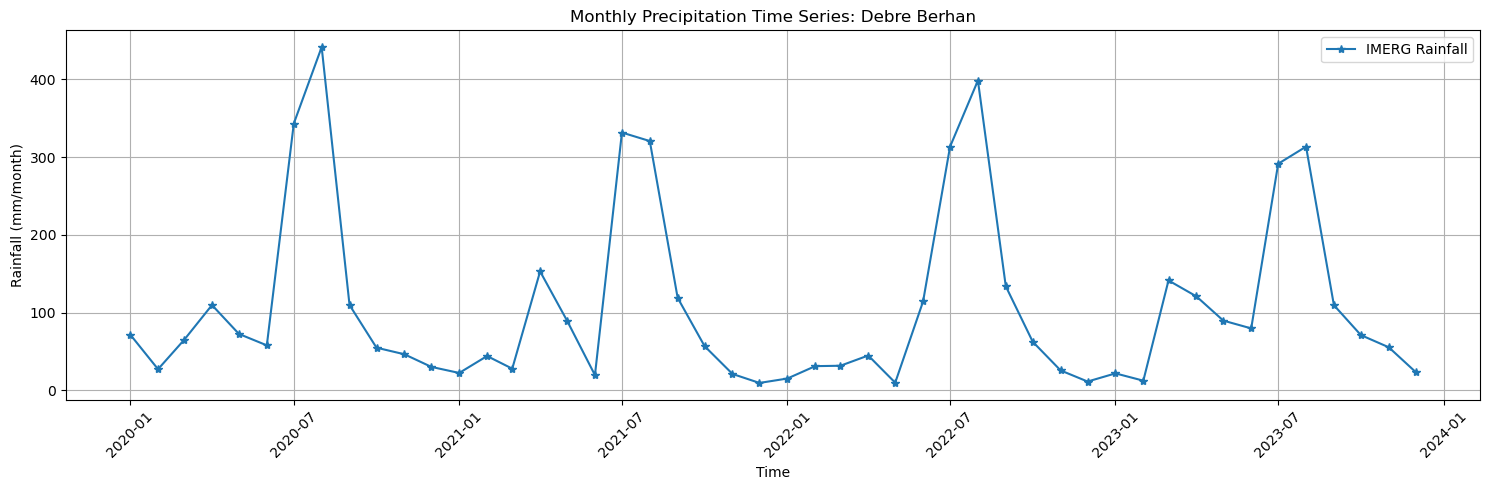

<Figure size 640x480 with 0 Axes>

In [20]:
# Select a specific station for visualization (Example: 7th station in the list)
# Using stn ==> the station name  as the column key to pull precipitation values
stn= imerg_monthly_data.columns[6]
plt.figure(figsize=(15, 5),layout='tight')
plt.plot(imerg_monthly_data[stn],label='IMERG Rainfall',marker='*')

# Adding labels
plt.xlabel('Time')
plt.ylabel('Rainfall (mm/month)')
plt.title(f'Monthly Precipitation Time Series: {stn}')
ax =plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))# Set ticks to occur every 6 months
# Rotate dates so they don't overlap
plt.xticks(rotation=45,ha='center')
plt.legend()
plt.grid(visible=True)
plt.tight_layout()
plt.show()
# Save the final figure with high resolution (300 DPI) for publications or reports
plt.savefig(f'Monthly Precipitation {stn}.png', format = 'png', dpi = 300)

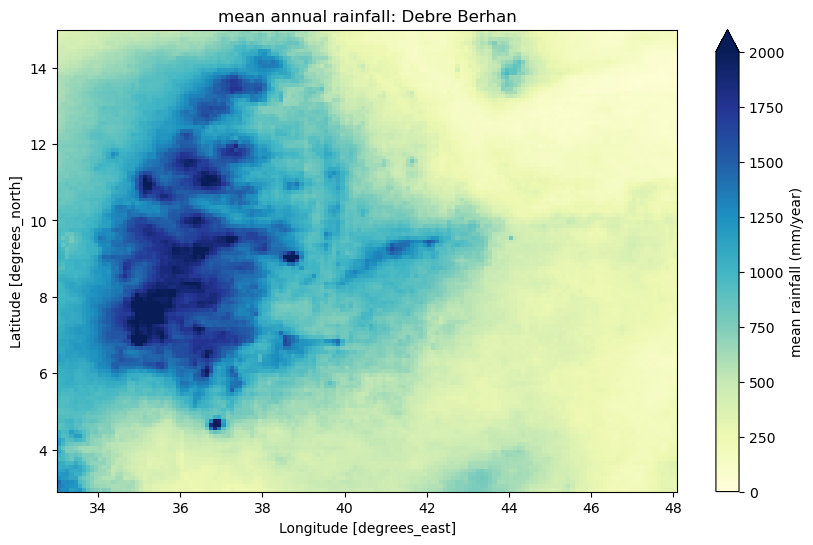

In [21]:
# 2D spatial map of the long-term Mean Annual Rainfal
mean_annual_rainfall.plot(vmin=0,
                          vmax=2000,
                          cmap='YlGnBu',
                          figsize=(10, 6), 
                          cbar_kwargs={'label': 'mean rainfall (mm/year)'}
                         );
plt.title(f'mean annual rainfall: {stn}')
# Save the final figure with high resolution (300 DPI) for publications or reports
plt.savefig(f'mean_annual_rainfall: {stn}.png', format = 'png', dpi = 300,bbox_inches='tight')